Custom Encoding

In [1]:
from typing import Iterable, Optional
import pandas as pd


class CategoricalEncoder:
    """
    Categorical encoder with an optional explicit categorical list
    using FREQUENCY ENCODING only.

    Behavior
    --------
    - Columns listed in `categorical_cols` are ALWAYS treated as categorical
      and encoded using relative frequencies, even if values look numeric.
    - Other columns are inferred:
        * If all non-missing values are numeric, the column is treated as numeric
          and passed through as float with NaNs imputed using the median.
        * Otherwise, the column is treated as categorical and frequency-encoded.

    Encoding details
    ---------------
    - Categorical values are encoded as relative frequencies only.
    - During `fit`, missing values are imputed (mode for categorical, median for numeric).
    - During `transform`, the SAME learned imputations are applied.
    - Unseen categories are encoded as `freq_unknown_value`.

    Attributes
    ----------
    feature_types_ : dict[str, str]
        Column -> {"numeric","categorical"} inferred during fit.
    freq_maps_ : dict[str, dict]
        Per categorical column: category -> relative frequency.
    numeric_imputers_ : dict[str, float]
        Per numeric column: median value.
    categorical_imputers_ : dict[str, str]
        Per categorical column: mode value.
    fitted_ : bool
        Whether `fit()` has been called.
    """

    def __init__(
        self,
        *, # The * means everything after it MUST be passed by name
        freq_unknown_value: float = 0.0, 
        categorical_cols: Optional[Iterable[str]] = None, # something you can loop over that contains strings(list, set, tuple, etc.)
    ):                                                    # Optional[...] → either that type or None,  = None → default value is None
        """
        Initialize the encoder.
        """
        self.freq_unknown_value = float(freq_unknown_value)  # value for unseen categories
        self.categorical_cols = set(categorical_cols or [])  # explicit categorical columns

        self.freq_maps_: dict[str, dict] = {}                # category -> relative frequency
        self.numeric_imputers_: dict[str, float] = {}        # column -> median
        self.categorical_imputers_: dict[str, str] = {}     # column -> mode
        self.feature_types_: dict[str, str] = {}             # column -> type
        self.numeric_like_categoricals_: set[str] = set()
        self.fitted_: bool = False                            # fit flag

    def _is_numeric_allowing_nans(self, s: pd.Series) -> bool:
        """
        Check if a column is numeric-like (ignoring missing values).
        """
        s_no_na = s.dropna()  # drop missing values
        if s_no_na.empty:     # all missing → treat as numeric
            return True
        return pd.to_numeric(s_no_na, errors="coerce").notna().all() #Tries to convert every value to a number, 
                                                                     #If a value cannot be converted → it becomes NaN
                                                                     #Checks which values are NOT NaN
                                                                     #Returns True only if ALL values are True
    def _validate_columns(self, df: pd.DataFrame) -> None:  
        """
        Ensure user-specified categorical columns exist.
        """
        missing = self.categorical_cols - set(df.columns)
        if missing:
            raise ValueError(f"Categorical columns not found: {sorted(missing)}")

    def fit(self, X) -> "CategoricalEncoder":
        """
        Learn imputations, frequency encodings, and feature types.
        """
        df = pd.DataFrame(X).copy()
        self._validate_columns(df)

        #These four lines reset the encoder’s memory before learning from new data.
        self.freq_maps_.clear()
        self.numeric_imputers_.clear()
        self.categorical_imputers_.clear()
        self.feature_types_.clear()
        self.numeric_like_categoricals_.clear()

        for col in df.columns:
            s = df[col]

            if col in self.categorical_cols:
                # NEW: check if it's actually numeric-like
                if self._is_numeric_allowing_nans(s):
                    # Treat as numeric instead
                    s_num = pd.to_numeric(s, errors="coerce")
                    self.numeric_imputers_[col] = s_num.median()
                    self.feature_types_[col] = "categorical"
                    self.numeric_like_categoricals_.add(col)   # 🔥 key line


                else:
                    # Explicit categorical → mode imputation + frequency encoding
                    s_str = s.astype("string")

                    mode = s_str.dropna().mode()
                    self.categorical_imputers_[col] = mode.iloc[0] if not mode.empty else "__MISSING__"

                    freqs = (
                        s_str.fillna(self.categorical_imputers_[col])
                        .value_counts(normalize=True) #Counts how often each value appears,  Divides by the total number of values
                                                    # Returns relative frequencies (proportions) instead of raw counts
                    )

                    self.freq_maps_[col] = freqs.to_dict()
                    self.feature_types_[col] = "categorical"

            elif self._is_numeric_allowing_nans(s):
                # Numeric → median imputation
                s_num = pd.to_numeric(s, errors="coerce") #Tries to convert every value in s into a number,  If a value cannot be converted → it becomes NaN
                self.numeric_imputers_[col] = s_num.median()
                self.feature_types_[col] = "numeric"

            else:
                # Inferred categorical → mode imputation + frequency encoding
                s_str = s.astype("string")

                mode = s_str.dropna().mode()
                self.categorical_imputers_[col] = mode.iloc[0] if not mode.empty else "__MISSING__"

                freqs = (
                    s_str.fillna(self.categorical_imputers_[col])
                    .value_counts(normalize=True)
                )

                self.freq_maps_[col] = freqs.to_dict()
                self.feature_types_[col] = "categorical"

        self.fitted_ = True
        return self

    def transform(self, X) -> pd.DataFrame:
        """
        Apply learned imputations and frequency encodings.
        """
        if not self.fitted_:
            raise RuntimeError("Call fit() before transform().")

        df = pd.DataFrame(X).copy()
        out = pd.DataFrame(index=df.index)

        for col in df.columns:
            ftype = self.feature_types_.get(col, "numeric") # If the column was NOT seen, it defaults to "numeric"

            if ftype == "numeric" or col in self.numeric_like_categoricals_:                # Numeric passthrough with median imputation
                median = self.numeric_imputers_.get(col, 0.0)
                out[col] = (
                    pd.to_numeric(df[col], errors="coerce")
                    .fillna(median)
                    .astype(float)
                )
            else:
                # Categorical mode imputation + frequency encoding
                fill_value = self.categorical_imputers_.get(col, "__MISSING__")
                freq_map = self.freq_maps_.get(col, {}) #Tries to get the frequency map for this column

                out[col] = (
                    df[col].astype("string") #Converts values to pandas’ string type
                    .fillna(fill_value) #Replaces missing values, So categorical NaNs → mode
                    .map(freq_map) #Replaces each category with its relative frequency (Known category → its frequency,Unknown category → NaN)
                    .fillna(self.freq_unknown_value) #Handles unseen categories, Any value not in freq_map → freq_unknown_value
                    .astype(float) #Ensures the final column is numeric
                )

        return out

    def fit_transform(self, X) -> pd.DataFrame:
        """
        Fit and transform in one step.
        """
        return self.fit(X).transform(X)

    def get_freq_maps(self) -> dict[str, dict]:
        """
        Return learned frequency maps.
        """
        return {k: dict(v) for k, v in self.freq_maps_.items()}

    def get_feature_types(self) -> dict[str, str]:
        """
        Return inferred feature types.
        """
        return dict(self.feature_types_)

Function for evaluation

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.base import clone


def evaluate_pkl_folder(folder_path, model):

    results = []
    results_per_fold = []
    for file in os.listdir(folder_path):

        if not file.endswith(".pkl"):
            continue

        file_path = os.path.join(folder_path, file)

        with open(file_path, "rb") as f:
            data = pickle.load(f)

        orig_r2, orig_nrmse, orig_nmae = [], [], []
        trans_r2, trans_nrmse, trans_nmae = [], [], []

        for fold in data.keys():

            X_train = data[fold]['X_train'].copy()
            X_test = data[fold]['X_test'].copy()
            X_train_trans = data[fold]['X_train_trans'].copy()
            X_test_trans = data[fold]['X_test_trans'].copy()
            y_train = data[fold]['y_train']
            y_test = data[fold]['y_test']

            # -----------------------
            # ORIGINAL FEATURES
            # -----------------------
            cat_cols = [
                col for col in X_train.columns
                if X_train[col].dtype == 'object' or str(X_train[col].dtype) == 'category'
            ]

            encoder = CategoricalEncoder(categorical_cols=cat_cols)


            X_train_enc = encoder.fit_transform(X_train)
            X_test_enc = encoder.transform(X_test)

            m = clone(model)
            m.fit(X_train_enc, y_train)
            preds = m.predict(X_test_enc)

            orig_r2.append(r2_score(y_test, preds))
            rmse = np.sqrt(mean_squared_error(y_test, preds))
            nrmse = rmse / (y_train.max() - y_train.min())
            orig_nrmse.append(nrmse) # Now storing NRMSE

            mae = mean_absolute_error(y_test, preds)
            nmae = mae / (y_train.max() - y_train.min())
            orig_nmae.append(nmae)

            # -----------------------
            # TRANSFORMED FEATURES
            # -----------------------
            m = clone(model)
            m.fit(X_train_trans, y_train)
            preds = m.predict(X_test_trans)

            trans_r2.append(r2_score(y_test, preds))

            rmse = np.sqrt(mean_squared_error(y_test, preds))
            nrmse = rmse / (y_train.max() - y_train.min())
            trans_nrmse.append(nrmse) # Now storing NRMSE

            mae = mean_absolute_error(y_test, preds)
            nmae = mae / (y_train.max() - y_train.min())
            trans_nmae.append(nmae)

        results.append({
            "Dataset": file.replace(".pkl", ""),
            "Orig_R2": np.mean(orig_r2),
            "Orig_NRMSE": np.mean(orig_nrmse),
            "Orig_NMAE": np.mean(orig_nmae),
            "Trans_R2": np.mean(trans_r2),
            "Trans_NRMSE": np.mean(trans_nrmse),
            "Trans_NMAE": np.mean(trans_nmae)
        })

    results_df = pd.DataFrame(results)
    # -----------------------
    # IMPROVEMENT CALCULATION
    # -----------------------

    # results_df["R2_Improvement_%"] = (
    #     (results_df["Trans_R2"] - results_df["Orig_R2"])
    #     / results_df["Orig_R2"].abs()
    # ) * 100

    results_df["NRMSE_Improvement_%"] = (
        (results_df["Orig_NRMSE"] - results_df["Trans_NRMSE"])
        / results_df["Orig_NRMSE"]
    ) * 100

    # results_df["NMAE_Improvement_%"] = (
    #     (results_df["Orig_NMAE"] - results_df["Trans_NMAE"])
    #     / results_df["Orig_NMAE"]
    # ) * 100

    # # -----------------------
    # # R2 IMPROVEMENT PLOT
    # # -----------------------

    # fig, ax = plt.subplots(figsize=(10,5))

    x = np.arange(len(results_df))

    # ax.bar(x, results_df["R2_Improvement_%"])

    # ax.set_xticks(x)
    # ax.set_xticklabels(results_df["Dataset"], rotation=90)
    # ax.set_ylabel("R2 Improvement (%)")
    # ax.set_title("Percentage R2 Improvement (Transformed vs Original)")

    # plt.tight_layout()
    # plt.show()


    # -----------------------
    # RMSE IMPROVEMENT PLOT
    # -----------------------

    fig, ax = plt.subplots(figsize=(10,5))

    ax.bar(x, results_df["NRMSE_Improvement_%"])

    ax.set_xticks(x)
    ax.set_xticklabels(results_df["Dataset"], rotation=90)
    ax.set_ylabel("NRMSE Improvement (%)")
    ax.set_title("Percentage NRMSE Improvement (Transformed vs Original)")

    plt.tight_layout()
    plt.show()
    del(results_df['NRMSE_Improvement_%'])

    # # -----------------------
    # # NMAE IMPROVEMENT PLOT
    # # -----------------------

    # fig, ax = plt.subplots(figsize=(10,5))

    # ax.bar(x, results_df["NMAE_Improvement_%"])

    # ax.set_xticks(x)
    # ax.set_xticklabels(results_df["Dataset"], rotation=90)
    # ax.set_ylabel("NMAE Improvement (%)")
    # ax.set_title("Percentage NMAE Improvement (Transformed vs Original)")

    # plt.tight_layout()
    # plt.show()

    return results_df

LR

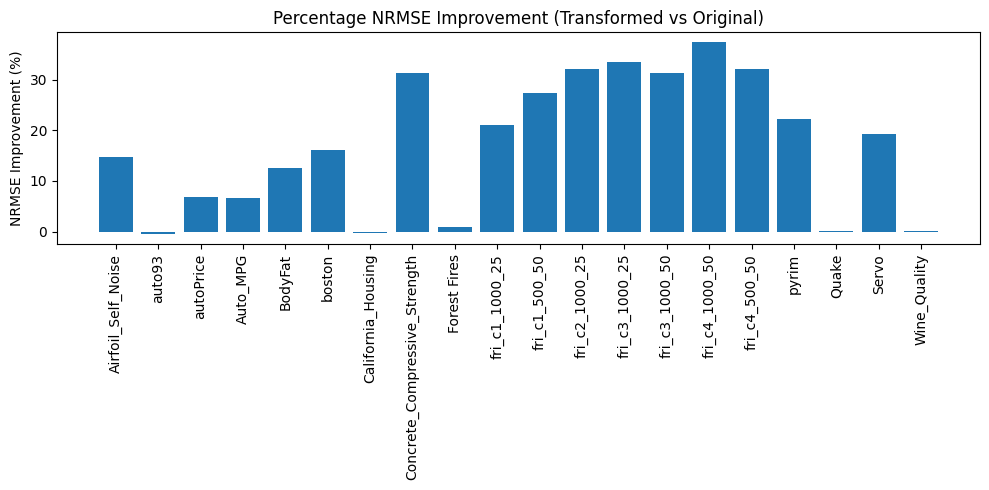

In [62]:
from sklearn.linear_model import LinearRegression

results_lr = evaluate_pkl_folder(
    folder_path="Data/All Data/Transformed_Data/Linear Regression",
    model=LinearRegression()
)

KNN

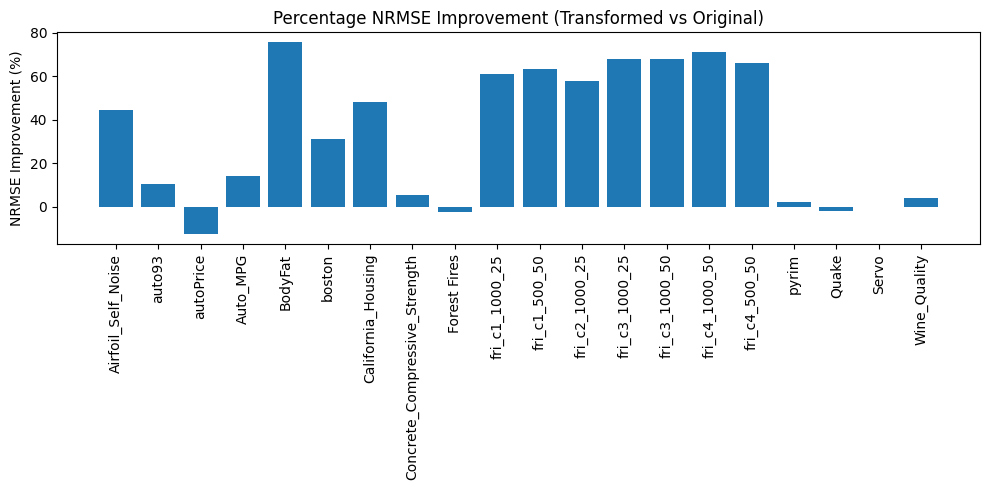

In [8]:
from sklearn.neighbors import KNeighborsRegressor

results_KNN = evaluate_pkl_folder(
    folder_path="Data/All Data/Transformed_Data/KNN",
    model=KNeighborsRegressor()
)

MLP

c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_netw

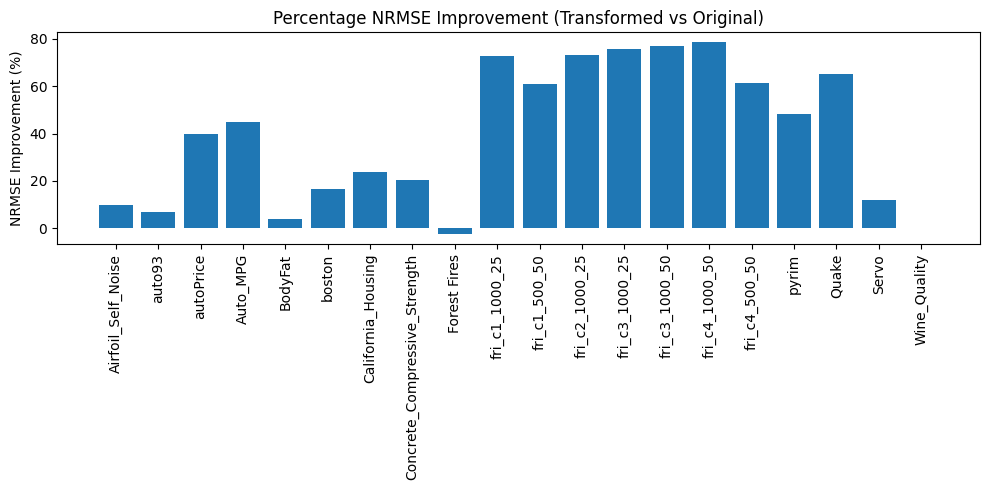

In [10]:
from sklearn.neural_network import MLPRegressor

results_MLP = evaluate_pkl_folder(
    folder_path="Data/All Data/Transformed_Data/MLP",
    model=MLPRegressor(random_state=42)
)

SVR

c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py

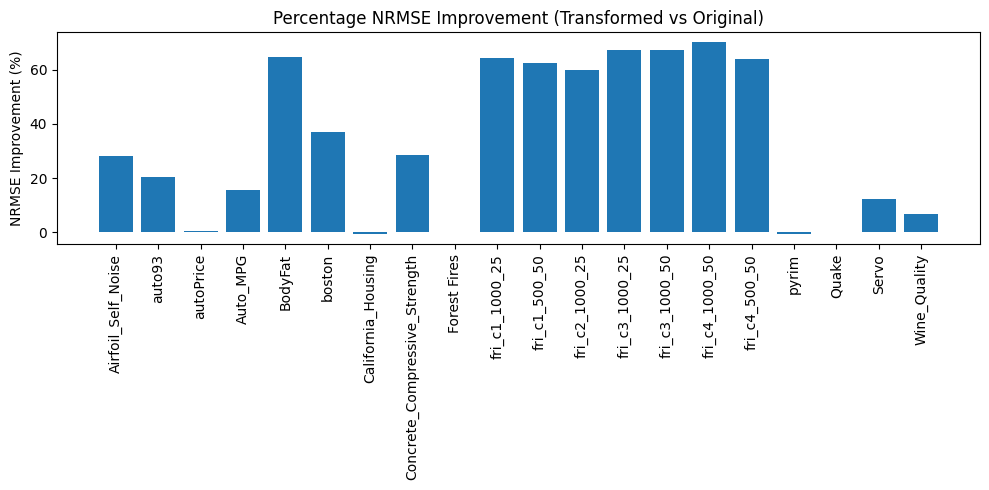

In [12]:
from sklearn.svm import SVR

results_SVR = evaluate_pkl_folder(
    folder_path="Data/All Data/Transformed_Data/SVR",
    model=SVR()
)

DT

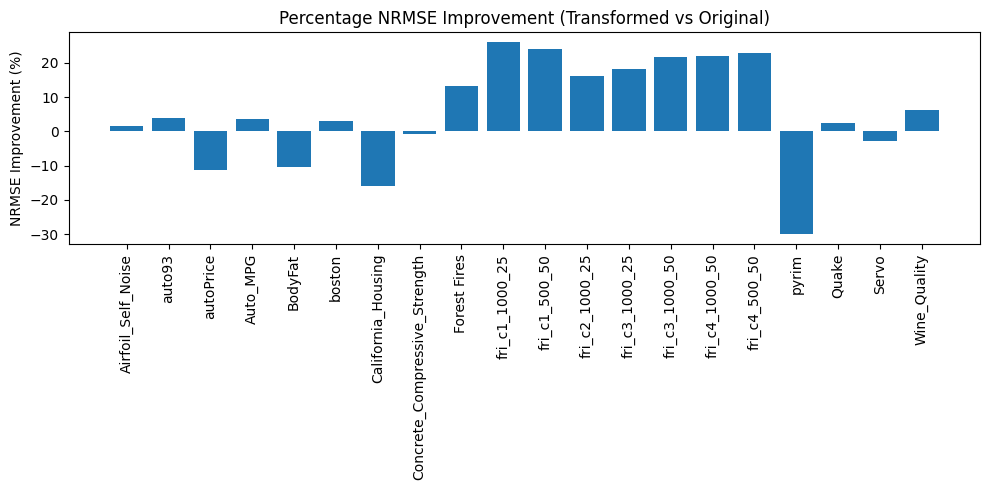

                          Dataset   Orig_R2  Orig_NRMSE  Orig_NMAE  Trans_R2  \
0              Airfoil_Self_Noise  0.848744    0.071408   0.051180  0.854689   
1                          auto93  0.059827    0.174280   0.108527  0.160309   
2                       autoPrice  0.784445    0.089066   0.058549  0.739035   
3                        Auto_MPG  0.735174    0.108020   0.072538  0.752266   
4                         BodyFat  0.956422    0.034679   0.011748  0.942082   
5                          boston  0.761935    0.098206   0.067873  0.774050   
6              California_Housing  0.615749    0.147455   0.094585  0.482292   
7   Concrete_Compressive_Strength  0.851537    0.080921   0.053104  0.849555   
8                    Forest Fires -7.355673    0.094086   0.027366 -3.147244   
9                  fri_c1_1000_25  0.705775    0.103480   0.081523  0.838978   
10                  fri_c1_500_50  0.546375    0.127951   0.100519  0.738331   
11                 fri_c2_1000_25  0.750

In [15]:
from sklearn.tree import DecisionTreeRegressor

results_DT = evaluate_pkl_folder(
    folder_path="Data/All Data/Transformed_Data/DT",
    model=DecisionTreeRegressor(random_state=42)
)

print(results_DT)

RF

c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389:

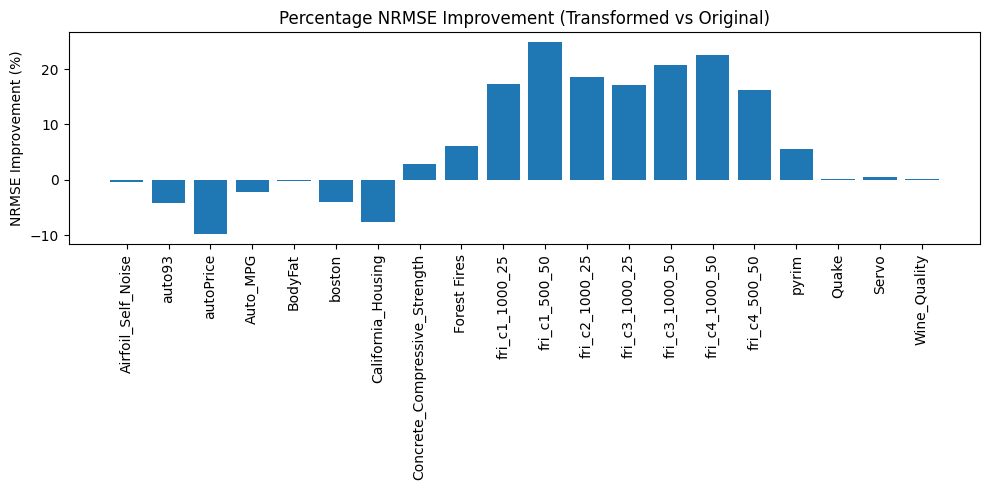

                          Dataset   Orig_R2  Orig_NRMSE  Orig_NMAE  Trans_R2  \
0              Airfoil_Self_Noise  0.929156    0.048981   0.035175  0.928655   
1                          auto93  0.611208    0.115133   0.075523  0.580130   
2                       autoPrice  0.851858    0.074172   0.049256  0.823726   
3                        Auto_MPG  0.869133    0.076693   0.053361  0.863523   
4                         BodyFat  0.967073    0.029005   0.009500  0.966039   
5                          boston  0.871432    0.072067   0.048766  0.860036   
6              California_Housing  0.809571    0.103789   0.067583  0.776319   
7   Concrete_Compressive_Strength  0.905774    0.064291   0.044227  0.911699   
8                    Forest Fires -1.388045    0.069438   0.023495 -0.949921   
9                  fri_c1_1000_25  0.871213    0.068238   0.054096  0.912404   
10                  fri_c1_500_50  0.788788    0.087293   0.068358  0.880945   
11                 fri_c2_1000_25  0.880

In [17]:
from sklearn.ensemble import RandomForestRegressor

results_RF = evaluate_pkl_folder(
    folder_path="Data/All Data/Transformed_Data/RF",
    model=RandomForestRegressor(random_state=42)
)

print(results_RF)

AB

c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py

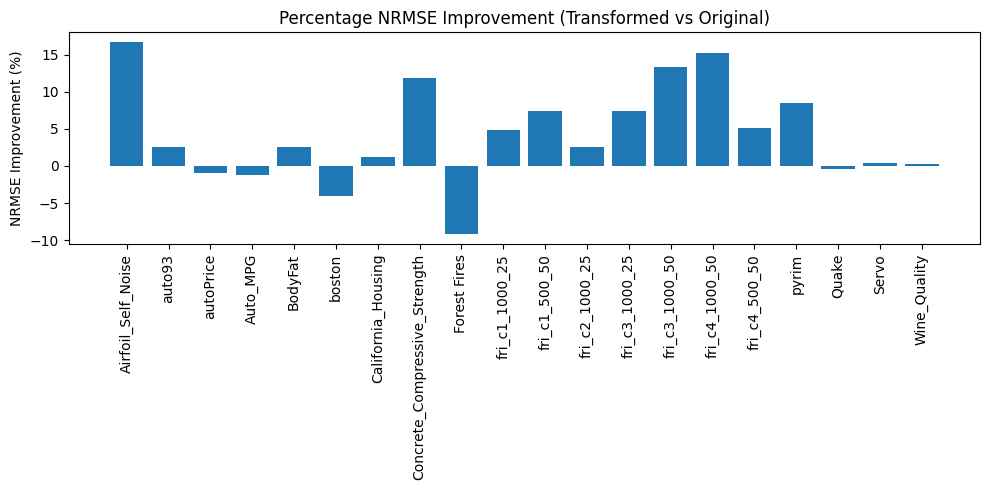

                          Dataset   Orig_R2  Orig_NRMSE  Orig_NMAE  Trans_R2  \
0              Airfoil_Self_Noise  0.683343    0.103855   0.084879  0.779749   
1                          auto93  0.506851    0.131356   0.087569  0.534189   
2                       autoPrice  0.855650    0.073108   0.052792  0.855980   
3                        Auto_MPG  0.835468    0.086114   0.062235  0.829876   
4                         BodyFat  0.947143    0.041893   0.024364  0.949613   
5                          boston  0.837228    0.080997   0.059667  0.823728   
6              California_Housing  0.466581    0.173616   0.147649  0.474655   
7   Concrete_Compressive_Strength  0.781855    0.098076   0.080585  0.830781   
8                    Forest Fires -1.153392    0.065434   0.025996 -1.474023   
9                  fri_c1_1000_25  0.795485    0.086440   0.070269  0.815324   
10                  fri_c1_500_50  0.751448    0.095073   0.075577  0.786821   
11                 fri_c2_1000_25  0.795

In [19]:
from sklearn.ensemble import AdaBoostRegressor

results_AB = evaluate_pkl_folder(
    folder_path="Data/All Data/Transformed_Data/AB",
    model=AdaBoostRegressor(random_state=42)
)

print(results_AB)

TEST

In [22]:
import pandas as pd
from scipy.stats import wilcoxon

# List of your result DataFrames and their corresponding display names
model_dfs = {
    'AdaBoost': results_AB,
    'Decision Tree': results_DT,
    'KNN': results_KNN,
    'Linear Regression': results_lr,
    'MLP': results_MLP,
    'SVR': results_SVR,
    'Random Forest': results_RF,

}

summary_data = []

for name, df in model_dfs.items():
    # Helper to safely run wilcoxon and return p-value
    # Using alternative='greater' for R2 (improvement means Trans > Orig)
    # Using alternative='less' for RMSE/NMAE (improvement means Trans < Orig)
    _, p_r2 = wilcoxon(df['Orig_R2'], df['Trans_R2'], alternative='less')
    _, p_rmse = wilcoxon(df['Orig_NRMSE'], df['Trans_NRMSE'], alternative='greater')
    _, p_nmae = wilcoxon(df['Orig_NMAE'], df['Trans_NMAE'], alternative='greater')
    
    summary_data.append({
        'Model': name,
        '$R^2$': p_r2,
        'NRMSE': p_rmse,
        'NMAE': p_nmae
    })

df_summary = pd.DataFrame(summary_data)

In [23]:
df_summary

,Model,$R^2$,NRMSE,NMAE
0,AdaBoost,0.008591,0.004154,0.000293
1,Decision Tree,0.024220,0.034790,0.094674
2,KNN,0.000558,0.000312,0.000146
3,Linear Regression,0.000031,0.000024,0.000007
4,MLP,0.000013,0.000003,0.000003
5,SVR,0.000041,0.000041,0.000010
6,Random Forest,0.014788,0.022027,0.024220


In [25]:
def bold_significant(val):
    # Check if the value is a number and below 0.05
    return 'font-weight: bold' if isinstance(val, (int, float)) and val < 0.05 else ''

# Apply styling and generate LaTeX
latex_table = df_summary.style.applymap(bold_significant, subset=['$R^2$', 'NRMSE', 'NMAE'])\
    .format(precision=8)\
    .hide(axis="index")\
    .to_latex(
        column_format='lccc',
        hrules=True,
        convert_css=True, # Critical: This converts 'font-weight: bold' to \mathbf or \textbf
        caption="Wilcoxon Signed-Rank Test P-Values (Original vs. AFE)",
        label="tab:wilcoxon_results",
        position='h!',
        position_float='centering'
    )

print(latex_table)

\begin{table}[h!]
\centering
\caption{Wilcoxon Signed-Rank Test P-Values (Original vs. AFE)}
\label{tab:wilcoxon_results}
\begin{tabular}{lccc}
\toprule
Model & $R^2$ & NRMSE & NMAE \\
\midrule
AdaBoost & \bfseries 0.00859070 & \bfseries 0.00415421 & \bfseries 0.00029278 \\
Decision Tree & \bfseries 0.02422047 & \bfseries 0.03479004 & 0.09467411 \\
KNN & \bfseries 0.00055781 & \bfseries 0.00031243 & \bfseries 0.00014628 \\
Linear Regression & \bfseries 0.00003147 & \bfseries 0.00002384 & \bfseries 0.00000668 \\
MLP & \bfseries 0.00001335 & \bfseries 0.00000286 & \bfseries 0.00000286 \\
SVR & \bfseries 0.00004101 & \bfseries 0.00004101 & \bfseries 0.00000954 \\
Random Forest & \bfseries 0.01478767 & \bfseries 0.02202702 & \bfseries 0.02422047 \\
\bottomrule
\end{tabular}
\end{table}



C:\Users\25644574\AppData\Local\Temp\ipykernel_15552\756236293.py:6: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  latex_table = df_summary.style.applymap(bold_significant, subset=['$R^2$', 'NRMSE', 'NMAE'])\
